# ⏩ Data Preparation

**Phase 1 :** Préparation des données ( Vérification,Nettoyage,Scaling)

In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/IA/Customer Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [56]:
pip install ydata-profiling

In [57]:
from ydata_profiling import ProfileReport
report = ProfileReport(df=df, title="CHURN CLINET")
report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 18.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [58]:
df.isnull().values.any()

np.False_

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [60]:
for col in df.columns:
    print(col, ":", df[col].unique()[:10])

customerID : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']
gender : ['Female' 'Male']
SeniorCitizen : [0 1]
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
tenure : [ 1 34  2 45  8 22 10 28 62 13]
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges : [ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15]
TotalCh

## ⏩⏩ **Detection des doublant**

In [61]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
nb_doublons = df.duplicated().sum()
print(f"Double : {nb_doublons}")

if nb_doublons > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Lignes après suppression : {len(df)}")

Double : 0


In [62]:
df['TotalCharges'] = df['TotalCharges'].str.replace(",", ".", regex=False)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.drop(columns=['customerID'])

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## 〰️**Outliers**

In [64]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} → {len(outliers)} outliers")

tenure → 0 outliers
MonthlyCharges → 0 outliers
TotalCharges → 0 outliers


In [65]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


## 👨‍💻**Encodage**

In [66]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split



# ── 3. Encodage cible ─────────────────────────────────────────────────────
label = LabelEncoder()
df['Churn'] = label.fit_transform(df['Churn'])

# ── 4. Encodage binaire ───────────────────────────────────────────────────
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
binary_map  = {'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1}
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# ── 5. One-Hot Encoding colonnes multi-classes ────────────────────────────
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print(f'Shape après encodage : {df.shape}')
df.head()

Shape après encodage : (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


# 🎯 Feature Selection – Gravitational Search Algorithm (GSA)

> **Phase 3** : L'agent est encodé en binaire (1 = feature sélectionnée, 0 = non sélectionnée). La fitness function minimise le **taux d'erreur** : `ErrorRate = (FP + FN) / (TP + TN + FP + FN)`.

In [67]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

class GSAFeatureSelector:
    """
    Gravitational Search Algorithm – Binary Feature Selection.
    Fitness = 1 - ErrorRate
    ErrorRate = (FP + FN) / (TP + TN + FP + FN)
    Agent dimension = nombre total de features.
    Agent[i] = 1 → feature sélectionnée, 0 → non sélectionnée.
    """
    def __init__(self, n_agents=20, max_iter=30, G0=100, alpha=20, random_state=42):
        self.n_agents    = n_agents
        self.max_iter    = max_iter
        self.G0          = G0      # Constante gravitationnelle initiale
        self.alpha       = alpha   # Taux de décroissance
        self.rs          = np.random.RandomState(random_state)
        self.best_mask_  = None
        self.best_score_ = 0.0
        self.history_    = []

    def _fitness(self, mask, Xtr, Xval, ytr, yval):
        """Fitness = 1 - ErrorRate (minimiser l'erreur = maximiser la fitness)"""
        if mask.sum() == 0:
            return 0.0
        clf = LogisticRegression(max_iter=300, random_state=0, solver='lbfgs')
        clf.fit(Xtr[:, mask], ytr)
        y_pred = clf.predict(Xval[:, mask])
        # Eq. 9 : ErrorRate = (FP + FN) / total
        error_rate = 1 - accuracy_score(yval, y_pred)
        return 1 - error_rate  # = accuracy

    def fit(self, X_train, y_train, X_val, y_val):
        n_features = X_train.shape[1]
        # Initialisation aléatoire des positions [0,1] et vitesses nulles
        pos = self.rs.rand(self.n_agents, n_features)
        vel = np.zeros_like(pos)

        for t in range(self.max_iter):
            # Constante gravitationnelle décroissante : G(t) = G0 * exp(-alpha * t/T)
            G = self.G0 * np.exp(-self.alpha * t / self.max_iter)

            # Binarisation : seuil 0.5
            masks = pos > 0.5
            fits  = np.array([
                self._fitness(m, X_train, X_val, y_train, y_val) for m in masks
            ])

            # Suivi du meilleur agent
            best_idx = fits.argmax()
            if fits[best_idx] > self.best_score_:
                self.best_score_ = fits[best_idx]
                self.best_mask_  = masks[best_idx].copy()
            self.history_.append(self.best_score_)

            # ── Masse inertielle (Eq. 3 & 4) ─────────────────────────────
            f_min, f_max = fits.min(), fits.max()
            if f_max == f_min:
                raw_masses = np.ones(self.n_agents)
            else:
                raw_masses = (fits - f_min) / (f_max - f_min + 1e-10)
            masses = raw_masses / (raw_masses.sum() + 1e-10)  # Eq. 4

            # ── Accélération (Eq. 2 & 5) ──────────────────────────────────
            acc = np.zeros_like(pos)
            for i in range(self.n_agents):
                for j in range(self.n_agents):
                    if i != j:
                        R = np.linalg.norm(pos[i] - pos[j]) + 1e-10  # Distance euclidienne Rij
                        F = G * masses[j] / R                         # Force Fij (Eq. 1)
                        acc[i] += F * (pos[j] - pos[i]) * self.rs.rand(n_features)  # rand = h

            # ── Mise à jour vitesse & position (Eq. 6 & 7) ───────────────
            h   = self.rs.rand(*vel.shape)  # h : random entre 0 et 1
            vel = h * vel + acc             # Vd_i(t+1) = h * Vd_i(t) + Ad_i(t)
            pos = np.clip(pos + vel, 0, 1)  # Ad_i(t+1) = Ad_i(t) + Vd_i(t+1)

            if (t + 1) % 5 == 0:
                print(f'  Iter {t+1:3d}/{self.max_iter} | '
                      f'Best Accuracy = {self.best_score_:.4f} | '
                      f'Features sélectionnées = {self.best_mask_.sum()}')
        return self

print('✅ Classe GSAFeatureSelector définie')


✅ Classe GSAFeatureSelector définie


# ➡️ Train/Test Split + Scaling

> **Phase 4 :** split 80/20, scaling après split pour éviter le data leakage.

In [68]:
# ── Split 80/20 stratifié (comme dans l'article) ────────────────────────
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── MinMaxScaler fit sur train uniquement ─────────────────────────────────
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Taux churn (train) : {y_train.mean():.2%}')

# ── Conversion numpy pour GSA ─────────────────────────────────────────────
Xtr_np = X_train.values.astype(float)
Xte_np = X_test.values.astype(float)
ytr_np = y_train.values
yte_np = y_test.values


Train : (5634, 30) | Test : (1409, 30)
Taux churn (train) : 26.54%


# ➡️ **Feature selection** GSA



In [69]:
from sklearn.model_selection import train_test_split as tts
import numpy as np

# Split interne pour la validation GSA (80% train / 20% val)
X_gsa_tr, X_gsa_val, y_gsa_tr, y_gsa_val = tts(
    Xtr_np, ytr_np, test_size=0.2, random_state=42, stratify=ytr_np
)

# Fill NaN values with 0 in the GSA training and validation sets
X_gsa_tr = np.nan_to_num(X_gsa_tr, nan=0.0)
X_gsa_val = np.nan_to_num(X_gsa_val, nan=0.0)

print('Lancement du GSA Feature Selection...')
gsa = GSAFeatureSelector(n_agents=20, max_iter=30, G0=100, alpha=10, random_state=42)
gsa.fit(X_gsa_tr, y_gsa_tr, X_gsa_val, y_gsa_val)

selected_features = X_train.columns[gsa.best_mask_].tolist()
print(f'\n✅ GSA Best Accuracy : {gsa.best_score_:.4f}')
print(f'✅ Features sélectionnées : {gsa.best_mask_.sum()} / {X_train.shape[1]}')
print(f'✅ features : {selected_features}')

Lancement du GSA Feature Selection...
  Iter   5/30 | Best Accuracy = 0.8225 | Features sélectionnées = 18
  Iter  10/30 | Best Accuracy = 0.8243 | Features sélectionnées = 16
  Iter  15/30 | Best Accuracy = 0.8243 | Features sélectionnées = 16
  Iter  20/30 | Best Accuracy = 0.8243 | Features sélectionnées = 16
  Iter  25/30 | Best Accuracy = 0.8243 | Features sélectionnées = 16
  Iter  30/30 | Best Accuracy = 0.8243 | Features sélectionnées = 16

✅ GSA Best Accuracy : 0.8243
✅ Features sélectionnées : 16 / 30
✅ features : ['gender', 'SeniorCitizen', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'InternetService_Fiber optic', 'OnlineBackup_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'PaymentMethod_Credit card (automatic)']


## 📉 **Courbe de Convergence du GSA**
> Évolution de la meilleure accuracy (1 − ErrorRate) au fil des itérations.
La courbe illustre la convergence de l'algorithme gravitationnel vers le sous-ensemble optimal de features.

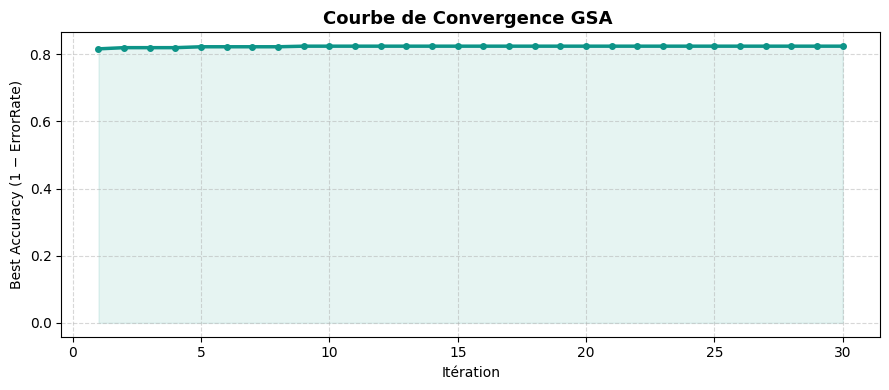

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(gsa.history_) + 1), gsa.history_,
         color='#0D9488', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(range(1, len(gsa.history_) + 1), gsa.history_,
                 alpha=0.1, color='#0D9488')
plt.title('Courbe de Convergence GSA ', fontsize=13, fontweight='bold')
plt.xlabel('Itération')
plt.ylabel('Best Accuracy (1 − ErrorRate)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# **GSA Feature Selection**

Utilisation du GSA pour sélectionner automatiquement les variables les plus pertinentes via un masque binaire (`best_mask_`).
Ce masque est ensuite appliqué aux données d’entraînement et de test afin de conserver uniquement les features optimales, réduire la dimensionnalité et améliorer les performances du modèle.

In [71]:
# Application du masque GSA sur train et test
X_train_gsa = Xtr_np[:, gsa.best_mask_]
X_test_gsa  = Xte_np[:, gsa.best_mask_]

# Handle potential NaNs remaining after feature selection
X_train_gsa = np.nan_to_num(X_train_gsa, nan=0.0)
X_test_gsa  = np.nan_to_num(X_test_gsa, nan=0.0)

print(f'X_train_gsa : {X_train_gsa.shape}')
print(f'X_test_gsa  : {X_test_gsa.shape}')

X_train_gsa : (5634, 16)
X_test_gsa  : (1409, 16)


# 4️⃣ K-Fold Cross Validation (k=5) – Phase 5

> **Phase 5** : K-Fold CV appliqué sur le train set pour l'hyperparameter tuning et prévenir l'overfitting.

In [72]:
pip install catboost

In [73]:
from sklearn.linear_model       import LogisticRegression
from sklearn.naive_bayes         import GaussianNB
from sklearn.svm                 import SVC
from sklearn.ensemble            import (RandomForestClassifier, ExtraTreesClassifier,
                                          AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.tree                import DecisionTreeClassifier
from sklearn.neighbors           import KNeighborsClassifier
from xgboost                     import XGBClassifier
from catboost                    import CatBoostClassifier
from sklearn.model_selection     import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# ── Définition de tous les modèles (Table 3 & Table 6 de l'article) ──────
models = {
    'Logistic Regression'          : LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree'                : DecisionTreeClassifier(random_state=42),
    'Naive Bayes (Gaussian)'       : GaussianNB(),
    'KNN Classifier'               : KNeighborsClassifier(n_neighbors=5),
    'SVM Classifier Linear'        : SVC(kernel='linear', probability=True, random_state=42),
    'SVM Classifier Poly'          : SVC(kernel='poly',   probability=True, random_state=42),
    'Random Forest'                : RandomForestClassifier(n_estimators=100, random_state=42),
    'Extra Tree Classifier'        : ExtraTreesClassifier(n_estimators=100, random_state=42),
    'Adaboost Classifier'          : AdaBoostClassifier(
                                         estimator=DecisionTreeClassifier(max_depth=1), # Explicitly define base estimator
                                         n_estimators=100, random_state=42, algorithm='SAMME'),
    'Adaboost (Extra Tree)'        : AdaBoostClassifier(
                                         estimator=ExtraTreesClassifier(n_estimators=10, random_state=42),
                                         n_estimators=50, random_state=42, algorithm='SAMME'),
    'Random Forest (Adaboost)'     : AdaBoostClassifier(
                                         estimator=RandomForestClassifier(n_estimators=10, random_state=42),
                                         n_estimators=50, random_state=42, algorithm='SAMME'),
    'Logistic Regression (Adaboost)': AdaBoostClassifier(
                                         estimator=LogisticRegression(max_iter=300, random_state=42),
                                         n_estimators=50, random_state=42, algorithm='SAMME'),
    'SVM (Adaboost)'               : AdaBoostClassifier(
                                         estimator=SVC(kernel='linear', probability=True, random_state=42),
                                         n_estimators=50, random_state=42, algorithm='SAMME'),
    'XGBoost Classifier'           : XGBClassifier(n_estimators=100, use_label_encoder=False,
                                                    eval_metric='logloss', random_state=42),
    'CatBoost Classifier'          : CatBoostClassifier(iterations=100, verbose=0, random_state=42)
}

# ── K-Fold CV (k=5) sur features GSA ─────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kfold_results = {}

print(f'{'Modèle':<35} CV Accuracy (k=5)')
print('─' * 55)
for name, clf in models.items():
    scores = cross_val_score(clf, X_train_gsa, ytr_np, cv=cv, scoring='accuracy', n_jobs=-1)
    kfold_results[name] = scores.mean() * 100
    print(f'{name:<35} {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

Modèle                              CV Accuracy (k=5)
───────────────────────────────────────────────────────
Logistic Regression                 80.25% ± 1.14%
Decision Tree                       72.91% ± 0.97%
Naive Bayes (Gaussian)              73.91% ± 0.83%
KNN Classifier                      77.25% ± 1.08%
SVM Classifier Linear               79.13% ± 0.98%
SVM Classifier Poly                 80.12% ± 0.59%
Random Forest                       78.72% ± 0.76%
Extra Tree Classifier               76.84% ± 0.50%
Adaboost Classifier                 79.73% ± 0.87%
Adaboost (Extra Tree)               76.87% ± 0.93%
Random Forest (Adaboost)            78.42% ± 0.73%
Logistic Regression (Adaboost)      78.49% ± 1.19%
SVM (Adaboost)                      73.46% ± 0.01%
XGBoost Classifier                  78.33% ± 1.00%
CatBoost Classifier                 80.30% ± 1.12%


In [74]:
import pandas as pd

# ── Tableau K-Fold (reproduction Table 3 de l'article) ───────────────────
kfold_df = pd.DataFrame.from_dict(kfold_results, orient='index',
                                   columns=['K-Fold CV Accuracy (%)'])
kfold_df = kfold_df.round(2).sort_values('K-Fold CV Accuracy (%)', ascending=False)

print('\n📊 K-Fold Cross Validation Results (cv=5) ')
print(kfold_df.to_string())



📊 K-Fold Cross Validation Results (cv=5) 
                                K-Fold CV Accuracy (%)
CatBoost Classifier                              80.30
Logistic Regression                              80.25
SVM Classifier Poly                              80.12
Adaboost Classifier                              79.73
SVM Classifier Linear                            79.13
Random Forest                                    78.72
Logistic Regression (Adaboost)                   78.49
Random Forest (Adaboost)                         78.42
XGBoost Classifier                               78.33
KNN Classifier                                   77.25
Adaboost (Extra Tree)                            76.87
Extra Tree Classifier                            76.84
Naive Bayes (Gaussian)                           73.91
SVM (Adaboost)                                   73.46
Decision Tree                                    72.91


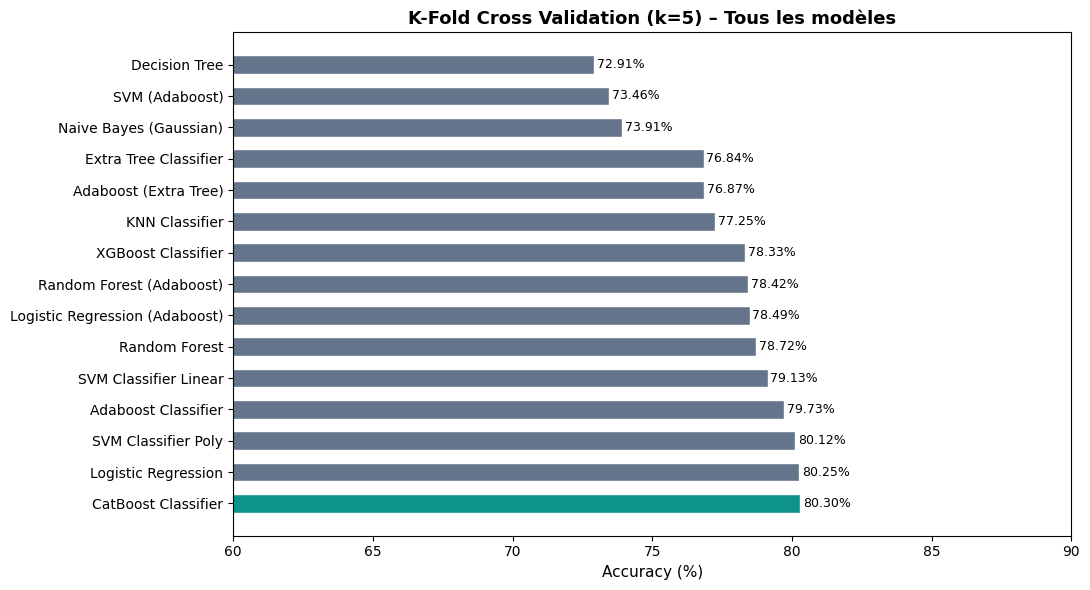

In [75]:
# ── Visualisation K-Fold Results ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#0D9488' if i == 0 else '#64748B' for i in range(len(kfold_df))]
bars = ax.barh(kfold_df.index, kfold_df['K-Fold CV Accuracy (%)'],
               color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, kfold_df['K-Fold CV Accuracy (%)']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('K-Fold Cross Validation (k=5) – Tous les modèles', fontsize=13, fontweight='bold')
ax.set_xlim(60, 90)
plt.tight_layout()
plt.show()


# 🚃 Entraînement & Évaluation sur le Test Set – Phase 4 & 6

> **Phase 6** : Évaluation via Confusion Matrix et AUC Curve sur le test set. Métriques : Accuracy, Recall, Precision, F-Measure et AUC Score .

In [76]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)

results = {}
print(f'{'Modèle':<35} {'Acc':>7} {'Recall':>8} {'Prec':>8} {'F1':>8} {'AUC':>8}')
print('─' * 80)

for name, clf in models.items():
    clf.fit(X_train_gsa, ytr_np)
    y_pred  = clf.predict(X_test_gsa)
    y_proba = clf.predict_proba(X_test_gsa)[:, 1]

    acc  = accuracy_score(yte_np, y_pred)  * 100
    rec  = recall_score   (yte_np, y_pred)  * 100
    prec = precision_score(yte_np, y_pred)  * 100
    f1   = f1_score       (yte_np, y_pred)  * 100
    auc  = roc_auc_score  (yte_np, y_proba) * 100

    results[name] = {'Accuracy': acc, 'Recall': rec, 'Precision': prec,
                     'F-Measure': f1, 'AUC Score': auc,
                     'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba}
    print(f'{name:<35} {acc:7.2f} {rec:8.2f} {prec:8.2f} {f1:8.2f} {auc:8.2f}')


Modèle                                  Acc   Recall     Prec       F1      AUC
────────────────────────────────────────────────────────────────────────────────
Logistic Regression                   79.70    51.07    64.97    57.19    83.46
Decision Tree                         72.11    46.79    47.43    47.11    64.14
Naive Bayes (Gaussian)                72.96    75.40    49.39    59.68    79.93
KNN Classifier                        77.22    48.93    58.47    53.28    76.50
SVM Classifier Linear                 78.99    53.74    62.04    57.59    82.04
SVM Classifier Poly                   78.85    46.79    63.87    54.01    80.54
Random Forest                         77.00    44.12    58.93    50.46    80.33
Extra Tree Classifier                 76.37    47.33    56.55    51.53    78.23
Adaboost Classifier                   79.21    51.60    63.28    56.85    83.80
Adaboost (Extra Tree)                 76.86    43.58    58.63    50.00    73.43
Random Forest (Adaboost)              7

## 📊 Tableau Comparatif

In [77]:
metrics_df = pd.DataFrame({
    name: {k: v for k, v in scores.items() if k not in ('clf', 'y_pred', 'y_proba')}
    for name, scores in results.items()
}).T.round(2)

metrics_df = metrics_df.sort_values('AUC Score', ascending=False)
print('\n📊 Comparison Table')

metrics_df.style.background_gradient(cmap='Greens').format('{:.2f}')



📊 Comparison Table


,Accuracy,Recall,Precision,F-Measure,AUC Score
CatBoost Classifier,79.56,51.07,64.53,57.01,84.20
Adaboost Classifier,79.21,51.60,63.28,56.85,83.80
Logistic Regression,79.70,51.07,64.97,57.19,83.46
SVM Classifier Linear,78.99,53.74,62.04,57.59,82.04
XGBoost Classifier,77.57,48.40,59.54,53.39,81.11
SVM Classifier Poly,78.85,46.79,63.87,54.01,80.54
Random Forest,77.00,44.12,58.93,50.46,80.33
Naive Bayes (Gaussian),72.96,75.40,49.39,59.68,79.93
Logistic Regression (Adaboost),76.79,60.70,55.77,58.13,79.71
Extra Tree Classifier,76.37,47.33,56.55,51.53,78.23


## 📈 Fig. 7 – Accuracy, Recall, Precision, F-Measure de tous les modèles

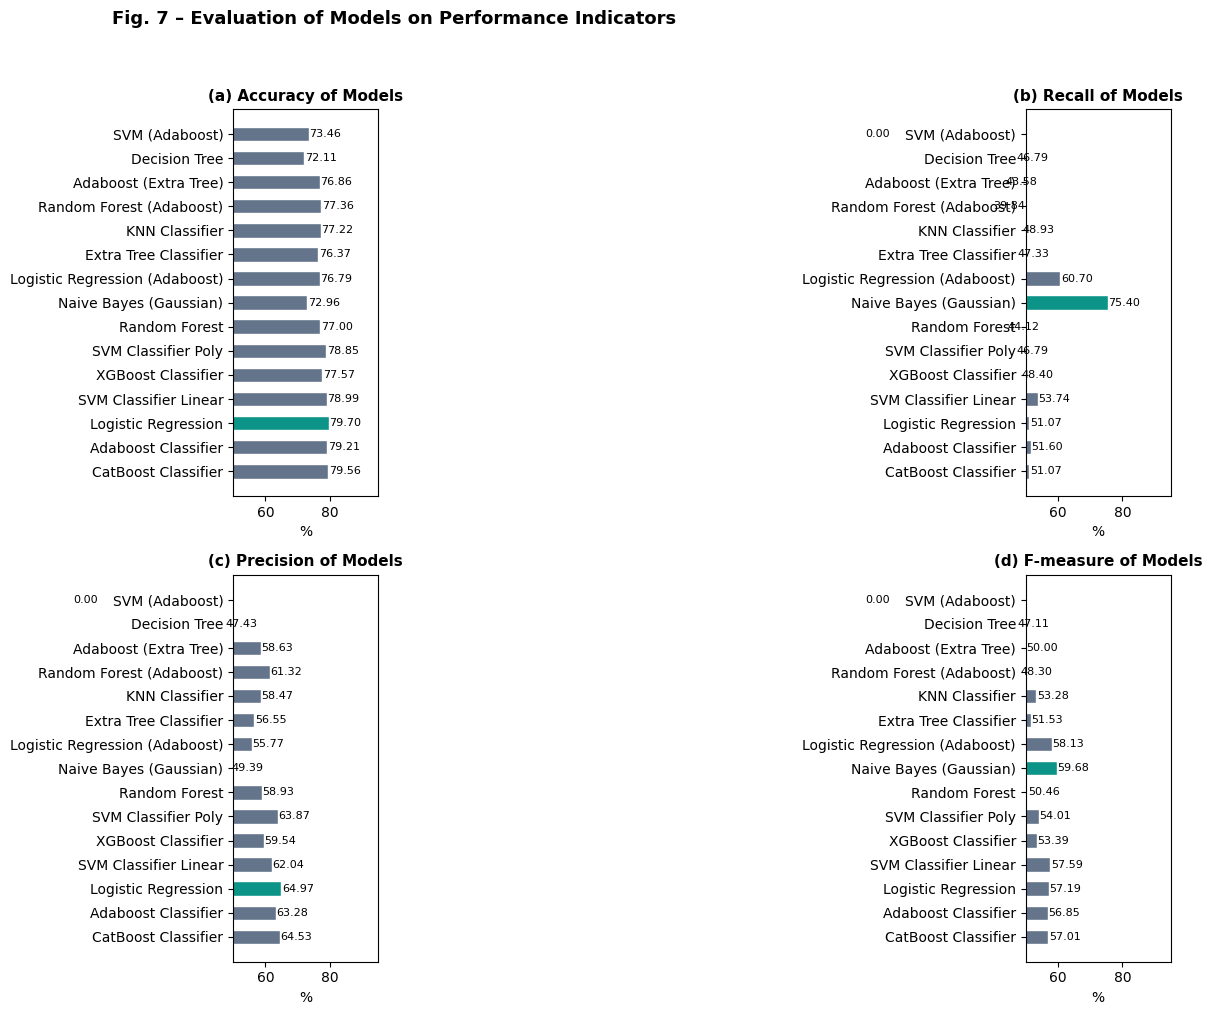

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_list = ['Accuracy', 'Recall', 'Precision', 'F-Measure']
titles_list  = ['(a) Accuracy of Models', '(b) Recall of Models',
                '(c) Precision of Models', '(d) F-measure of Models']
palette = ['#0D9488' if i == 0 else '#0EA5E9' for i in range(len(metrics_df))]

for ax, metric, title in zip(axes.flatten(), metrics_list, titles_list):
    data = metrics_df[metric]
    colors = ['#0D9488' if v == data.max() else '#64748B' for v in data]
    ax.barh(data.index, data.values, color=colors, edgecolor='white', height=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('%')
    ax.set_xlim(50, 95)
    for i, (val, name) in enumerate(zip(data.values, data.index)):
        ax.text(val + 0.2, i, f'{val:.2f}', va='center', fontsize=8)

plt.suptitle('Fig. 7 – Evaluation of Models on Performance Indicators\n',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 🔲 Confusion Matrices – tous les modèles

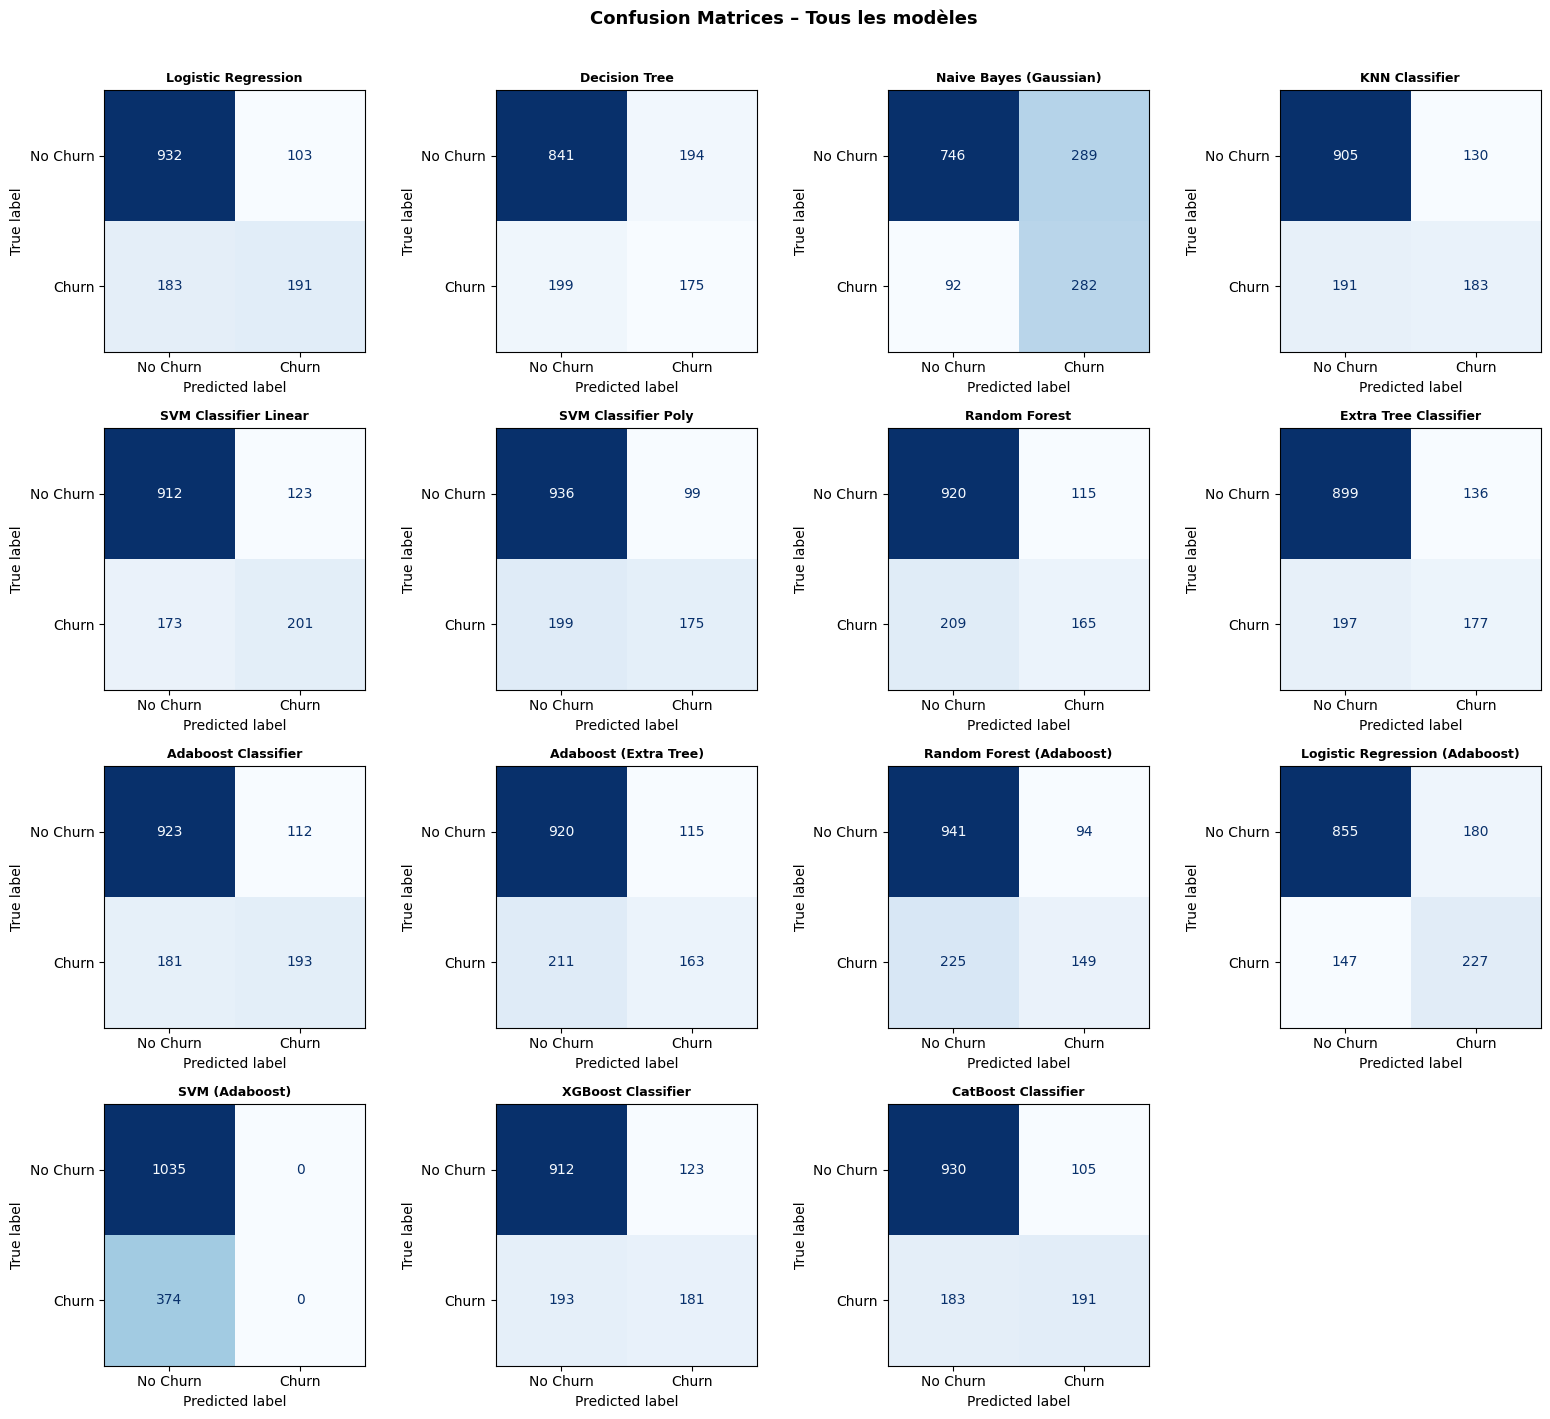

In [79]:
n_models = len(results)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for ax in axes[n_models:]:
    ax.set_visible(False)

for idx, (name, scores) in enumerate(results.items()):
    cm   = confusion_matrix(yte_np, scores['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=9, fontweight='bold')

plt.suptitle('Confusion Matrices – Tous les modèles',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 📉 Fig. 6 – AUC Curves – tous les modèles

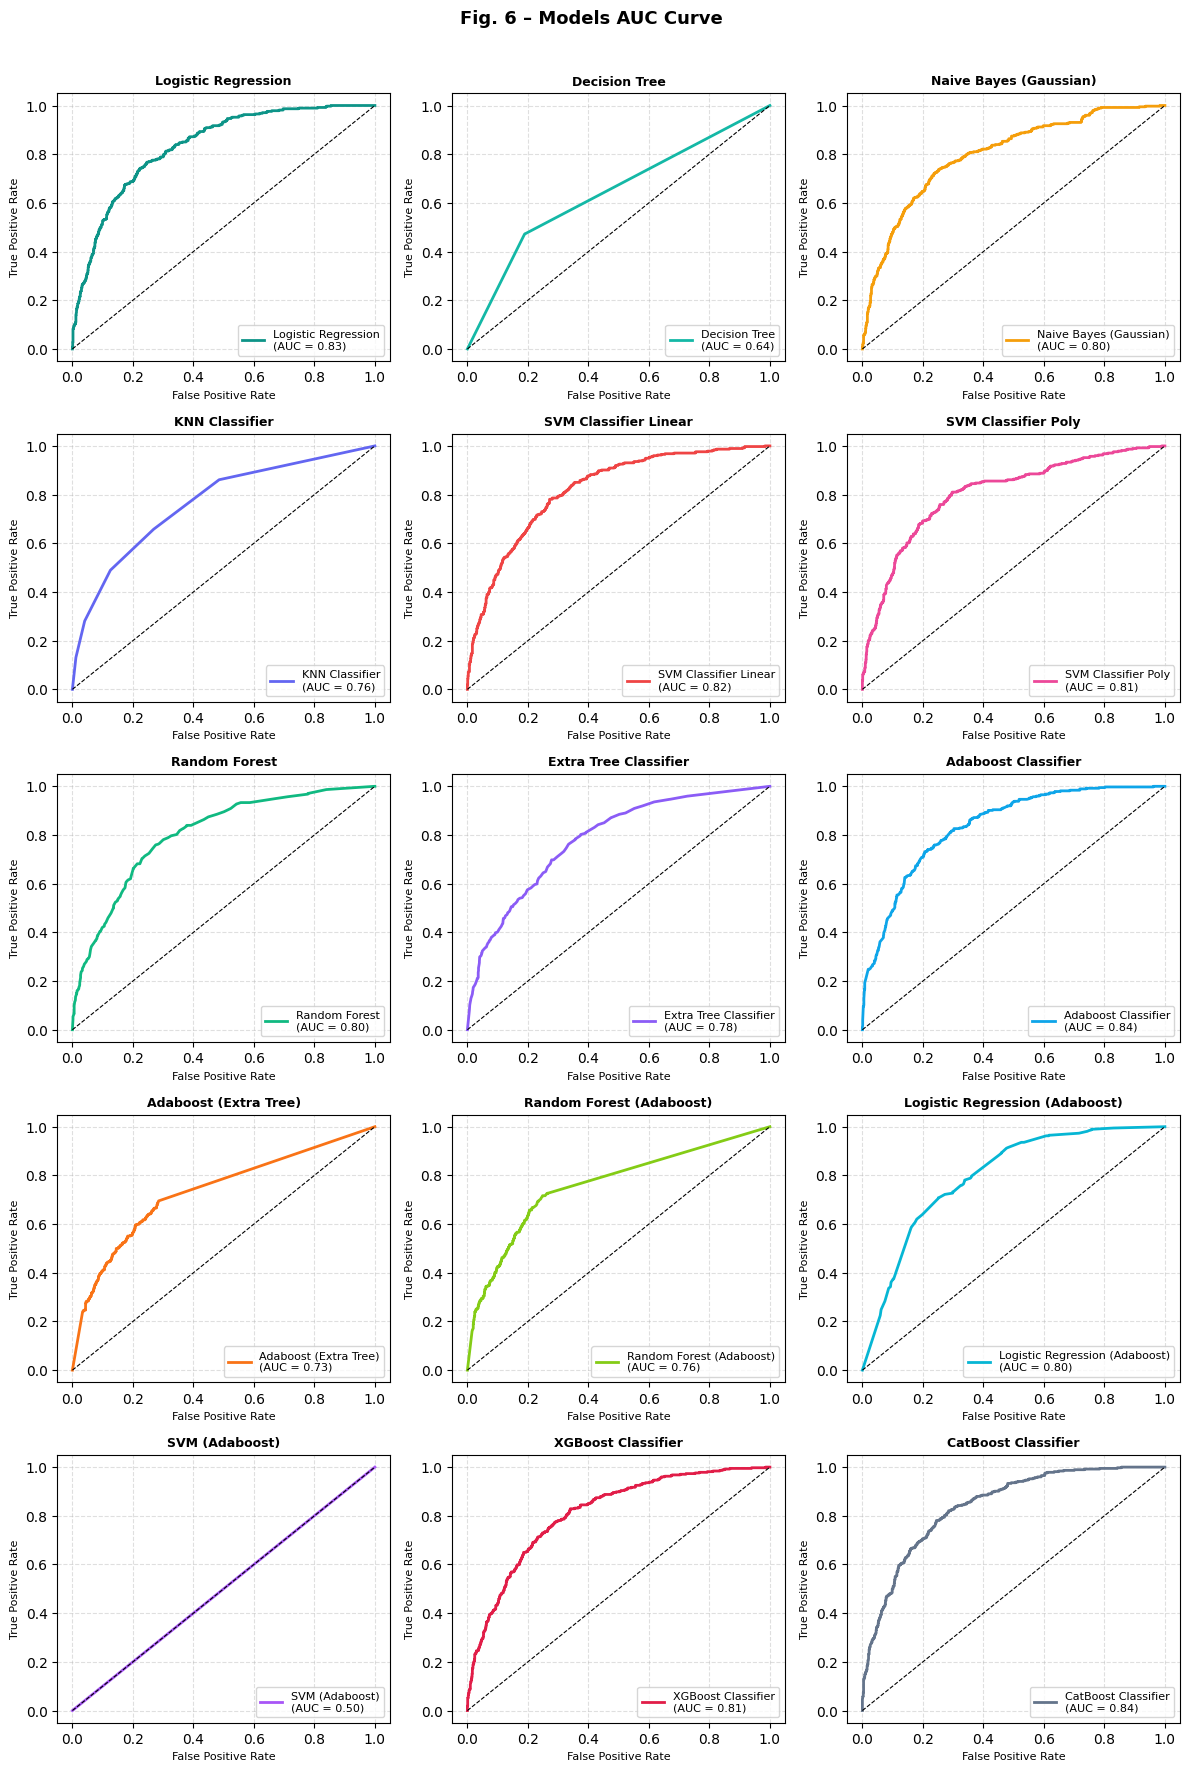

In [80]:
palette = ['#0D9488','#14B8A6','#F59E0B','#6366F1','#EF4444','#EC4899',
           '#10B981','#8B5CF6','#0EA5E9','#F97316','#84CC16','#06B6D4',
           '#A855F7','#E11D48','#64748B']

n_models  = len(results)
ncols_auc = 3
nrows_auc = (n_models + ncols_auc - 1) // ncols_auc

fig, axes = plt.subplots(nrows_auc, ncols_auc, figsize=(ncols_auc * 4, nrows_auc * 3.5))
axes = axes.flatten()

for ax in axes[n_models:]:
    ax.set_visible(False)

for idx, ((name, scores), color) in enumerate(zip(results.items(), palette)):
    fpr, tpr, _ = roc_curve(yte_np, scores['y_proba'])
    axes[idx].plot(fpr, tpr, color=color, linewidth=2,
                   label=f"{name}\n(AUC = {scores['AUC Score']/100:.2f})")
    axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    axes[idx].set_title(name, fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('False Positive Rate', fontsize=8)
    axes[idx].set_ylabel('True Positive Rate', fontsize=8)
    axes[idx].legend(fontsize=8, loc='lower right')
    axes[idx].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Fig. 6 – Models AUC Curve ',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 🏆 Meilleur Modèle – Synthèse finale

In [81]:
champion = metrics_df['AUC Score'].idxmax()
best      = metrics_df.loc[champion]
print('=' * 50)
print(f'  🏆 MEILLEUR MODÈLE : {champion}')
print('=' * 50)
print(f'  Accuracy  : {best["Accuracy"]:.2f}%')
print(f'  Recall    : {best["Recall"]:.2f}%')
print(f'  Precision : {best["Precision"]:.2f}%')
print(f'  F-Measure : {best["F-Measure"]:.2f}%')
print(f'  AUC Score : {best["AUC Score"]:.2f}%')
print('─' * 50)
print('Référence article : AdaBoost = 81.71%, AUC = 84%')
print('                    XGBoost  = 80.80%, AUC = 84%')


  🏆 MEILLEUR MODÈLE : CatBoost Classifier
  Accuracy  : 79.56%
  Recall    : 51.07%
  Precision : 64.53%
  F-Measure : 57.01%
  AUC Score : 84.20%
──────────────────────────────────────────────────
Référence article : AdaBoost = 81.71%, AUC = 84%
                    XGBoost  = 80.80%, AUC = 84%
